# Framework Comparison: Native SDK vs CrewAI vs LangGraph

**Docker image**: `ml4t`

The pipeline of NB04–NB08 was built end-to-end with plain Python classes,
no orchestration framework. That choice keeps every transition visible and
every artifact inspectable, but it pushes the reader to write the
orchestration logic by hand. The agentic-framework ecosystem offers
alternatives that automate parts of that work in exchange for adopting a
framework's conventions.

This notebook expresses the same four-phase forecasting flow in three
styles, but with a deliberate asymmetry:

1. **Native Python SDK**: direct composition of the chapter's
   `ResearchAgent` / `DebateAgent` / `SupervisorAgent` classes, same shape
   as `AIAForecaster` in NB08.
2. **CrewAI**: *role-prompted approximation* of the same flow. CrewAI's
   primitives (`Agent`, `Task`, `Crew`) drive an LLM via LiteLLM with
   role / goal / backstory prompts; the CrewAI variant does not wrap the
   chapter's specialist classes or share their search-tool surface.
3. **LangGraph**: pipeline as a `StateGraph` with typed state and four
   nodes that delegate to the same specialist classes the native variant
   uses.

The point of comparison is the **orchestration layer**: how each
framework expresses a four-phase flow, where state lives, and what
happens when something fails midway. Because Variant B is the
role-prompted CrewAI approximation rather than a wrap of the same agent
classes, the final probabilities should be compared as
"framework-shaped flows" rather than as a controlled benchmark of the
orchestration layer alone.

**Learning objectives**:
- See the same specialist → aggregate → debate → supervise pattern in three
  frameworks
- Compare notebook-owned orchestration size and inspect how each implementation
  exposes state, dependencies, and debugging entry points
- Build a defensible "start native, migrate when justified" decision rule

**Book reference**: §24.5 (The Engineering Stack: Frameworks and Migration).

**Prerequisites**: NB04-NB08 (specialist classes and forecasting pipeline used by Variants A and C).

**Replay vs live mode**: by default (`RUN_LIVE = False`) the notebook replays a
pinned 2026-06-09 claude-sonnet run. It reloads the saved native and LangGraph
traces, makes no API calls, and reports the genuine measured numbers, so the
comparison is reproducible. Set `RUN_LIVE = True` to run all three variants
live: Variants A and C go through the chapter's `LLMClient` (use
`LLM_PROVIDER=mock` for the `MockLLMClient`, or leave it empty to auto-detect a
real provider), while Variant B uses CrewAI's native LiteLLM layer and needs one
of `OPENAI_API_KEY` / `ANTHROPIC_API_KEY` / `GOOGLE_API_KEY` /
`OPENROUTER_API_KEY`; without a key the live path skips Variant B and prints a note.

In [1]:
"""Framework comparison: same four-phase pipeline in native, CrewAI, LangGraph."""

import ast
import inspect
import os
import textwrap
import time
import warnings
from typing import TypedDict

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import polars as pl
from agent_fixtures import get_chapter_contested_question
from agent_observability import TRACES_DIR, RunTrace, replay_llm_calls, trace_llm
from agent_pipeline import neyman_extremize
from agent_providers import create_llm_client
from agent_research import ResearchAgent, format_agent_summary
from agent_schemas import AgentForecastArtifact
from agent_specialists import DebateAgent, SupervisorAgent
from agent_tools import create_search_client

from utils.style import COLORS, FIGSIZE, add_message_title

In [2]:
# RUN_LIVE=False (the default) replays the pinned 2026-06-09 claude-sonnet run:
# the notebook reloads the saved native + LangGraph traces named below, makes no
# API calls, and reports the genuine measured numbers, so the comparison is
# stable and matches the chapter. Set RUN_LIVE=True (with API keys) to run all
# three variants live against a current question; that path produces different
# numbers and is not reproducible.
RUN_LIVE = False
PINNED_TRACES = {
    "native_sdk": "10_framework_comparison_20260609T150909Z_ba1855847f4c.json",
    "langgraph": "10_framework_comparison_20260609T151202Z_c8cba3007562.json",
}

LLM_PROVIDER = ""  # empty -> auto-detect; "mock" for CI (live path only)
N_AGENTS = 3
DEBATE_ROUNDS = 2
SUPERVISOR_QUERIES = 2
MAX_STEPS = 5  # research-agent reasoning budget; too small a budget leaves agents at the neutral 0.5 fallback

## Setup: one question, one LLM/search pair shared across variants

We use the pinned `CHAPTER_CONTESTED_QUESTION` (the same rate-hike question
NB04, NB07, and NB08 forecast), then run all three variants against it.
Holding the question fixed removes one source of variation. CrewAI still
changes the prompts, agent classes, search access, and client boundary, so
this is not a controlled runtime or forecast-quality benchmark.

In [3]:
if RUN_LIVE:
    llm = create_llm_client(LLM_PROVIDER)
    search = create_search_client(LLM_PROVIDER)
    question = get_chapter_contested_question()
    provider_name = llm.model_name
else:
    # Replay: reload the pinned native + LangGraph traces. The question and
    # provider come from the saved run; the live client/search are unused.
    pinned_native = RunTrace.load(TRACES_DIR / PINNED_TRACES["native_sdk"])
    pinned_langgraph = RunTrace.load(TRACES_DIR / PINNED_TRACES["langgraph"])
    llm = search = None
    question = pinned_native.question_obj()
    provider_name = pinned_native.provider

print(f"Mode:     {'LIVE' if RUN_LIVE else 'REPLAY (pinned 2026-06-09 trace)'}")
print(f"Question: {question.question}")
print(f"LLM:      {provider_name}")
print(f"Cutoff:   {question.cutoff_date}")

Mode:     REPLAY (pinned 2026-06-09 trace)
Question: Will the Federal Reserve hike rates in 2026?
LLM:      claude-sonnet-4-20250514
Cutoff:   


## Variant A: Native Python SDK

Direct composition of the chapter's classes. The orchestration is plain
Python: a function that calls the four phases in sequence, owns its own
state in local variables, and returns a dict. This is the form NB08
encapsulated as `AIAForecaster`.

Three properties earn it the "default" slot:
- state is whatever the function holds in scope; it lives nowhere else;
- failure modes are Python exceptions you can step through with any
  debugger;
- dependencies stop at the LLM SDK and the chapter's helper modules.

What it gives up is *automation*: nothing parallelizes the agent calls
unless you write the threading; nothing checkpoints intermediate state;
nothing visualizes the graph. Frameworks earn their keep by automating
those things. The question is whether the pipeline at hand is complex
enough to need them.

In [4]:
def native_sdk_pipeline(question, llm, search) -> dict:
    """Four-phase pipeline expressed as plain Python composition."""
    artifacts: list[AgentForecastArtifact] = []
    for i in range(N_AGENTS):
        agent = ResearchAgent(llm=llm, search=search, agent_id=f"agent_{i}", max_steps=MAX_STEPS)
        artifacts.append(agent.run(question, market_price=question.current_market_price))

    probs = [a.p_yes for a in artifacts]
    aggregate = neyman_extremize(probs, base=0.5, correlation=0.3)

    summaries = "\n\n".join(format_agent_summary(a) for a in artifacts)
    debate = DebateAgent(llm=llm, max_rounds=DEBATE_ROUNDS).run(
        question.question, summaries, aggregate.extremized_probability
    )
    debate_midpoint = (
        (debate.bull_final_probability + debate.bear_final_probability) / 2
        if debate.bull_final_probability is not None
        else aggregate.extremized_probability
    )

    supervisor = SupervisorAgent(llm=llm, search=search, max_queries=SUPERVISOR_QUERIES).run(
        question.question, summaries, cutoff_date=question.cutoff_date
    )

    final_p = debate_midpoint
    if supervisor.confidence == "high" and supervisor.p_yes is not None:
        final_p = supervisor.p_yes

    return {
        "framework": "native_sdk",
        "agent_probs": probs,
        "aggregate": aggregate.extremized_probability,
        "debate_midpoint": debate_midpoint,
        "supervisor_p": supervisor.p_yes,
        "supervisor_confidence": supervisor.confidence,
        "final_p": final_p,
    }

Because every chapter specialist talks to the model through one
`LLMClient`, wrapping that client in a `TracingLLMClient` records the whole
conversation with no change to the pipeline function. The orchestration
statement count we report below is unaffected. We pass the traced client in
place of `llm` so the native variant's run is fully auditable.

In [5]:
if RUN_LIVE:
    tracer_a = trace_llm(llm, label="native")
    t0 = time.perf_counter()
    result_a = native_sdk_pipeline(question, tracer_a, search)
    elapsed_a = time.perf_counter() - t0
    native_calls = tracer_a.calls
else:
    # Replay: the pinned native trace stores the computed result dict and the
    # measured wall-clock time in its params, plus the raw model conversation.
    result_a = pinned_native.params["result"]
    elapsed_a = pinned_native.params["elapsed_s"]
    native_calls = pinned_native.call_log()

print(f"=== Variant A: Native SDK ({elapsed_a:.1f}s) ===")
for i, p in enumerate(result_a["agent_probs"]):
    print(f"  agent_{i}: {p:.3f}")
print(f"  aggregate:        {result_a['aggregate']:.3f}")
print(f"  debate midpoint:  {result_a['debate_midpoint']:.3f}")
print(f"  supervisor:       {result_a['supervisor_p']} ({result_a['supervisor_confidence']})")
print(f"  FINAL:            {result_a['final_p']:.3f}")

=== Variant A: Native SDK (108.0s) ===
  agent_0: 0.250
  agent_1: 0.350
  agent_2: 0.350
  aggregate:        0.249
  debate midpoint:  0.300
  supervisor:       0.15 (medium)
  FINAL:            0.300


In [6]:
if RUN_LIVE:
    run_a = RunTrace.capture(
        notebook="10_framework_comparison",
        provider=provider_name,
        question=question,
        params={
            "variant": "native_sdk",
            "n_agents": N_AGENTS,
            "debate_rounds": DEBATE_ROUNDS,
            "supervisor_queries": SUPERVISOR_QUERIES,
            "max_steps": MAX_STEPS,
            # Persist the computed result and timing so a future replay can
            # reconstruct this variant's printout and table row without rerunning.
            "result": result_a,
            "elapsed_s": round(elapsed_a, 1),
        },
        final_probability=result_a["final_p"],
        llm_calls=native_calls,
        notes="Variant A (native SDK): raw model conversation captured at the client boundary.",
    )
    path_a = run_a.save()
    print(
        f"Saved {len(run_a.llm_calls)} native-variant calls "
        f"({run_a.total_tokens():,} tokens) → {path_a.name}"
    )
else:
    # Replay: report the pinned trace we loaded rather than writing a new file.
    print(
        f"Replayed {len(native_calls)} native-variant calls "
        f"({pinned_native.total_tokens():,} tokens) from {PINNED_TRACES['native_sdk']}"
    )

Replayed 21 native-variant calls (110,130 tokens) from 10_framework_comparison_20260609T150909Z_ba1855847f4c.json


## Variant B: CrewAI role-based agents in a `Crew`

CrewAI organizes agents around three named slots: a **role** label, a
**goal**, and a **backstory**. It lets you compose them into a `Crew`
whose `Process` (sequential or hierarchical) runs the work. Tasks declare
what each agent should produce and which other tasks' outputs it can read.

The pattern fits when the work decomposes into named personas with
distinct charters: research, debate, supervise. CrewAI also exposes
asynchronous tasks, retries, and verbose logging. This notebook uses a
sequential process so each task sees its dependencies. The cost is
that orchestration lives in the framework's data structures rather than
in your function call stack. When something goes sideways, the failure
surfaces inside CrewAI's loop rather than at the line that requested it.

**LLM layer**: CrewAI uses LiteLLM by default. Setting one of the
standard env vars (`OPENAI_API_KEY`, `ANTHROPIC_API_KEY`, etc.) is enough.
LiteLLM picks the provider, while the model is named via the `model=` string
(e.g. `"gpt-4.1-mini"`, `"anthropic/claude-sonnet-4"`,
`"openrouter/anthropic/claude-sonnet-4"`).

In [7]:
# Variant B drives CrewAI's own LiteLLM runtime, so it never passes through the
# chapter's LLMClient boundary and is not captured in a RunTrace (see the
# observability note further down). Under replay we therefore pin its genuine
# 2026-06-09 measured result rather than reloading it from a trace.
PINNED_CREWAI_RESULT = {
    "framework": "crewai",
    "agent_probs": [0.25, 0.25, 0.25],
    "aggregate": 0.1577,
    "debate_midpoint": 0.335,
    "supervisor_p": 0.25,
    "supervisor_confidence": "medium",
    "final_p": 0.335,
}
PINNED_CREWAI_ELAPSED_S = 70.3

LIVE_KEY_PRESENT = bool(
    os.environ.get("OPENAI_API_KEY")
    or os.environ.get("ANTHROPIC_API_KEY")
    or os.environ.get("GOOGLE_API_KEY")
    or os.environ.get("OPENROUTER_API_KEY")
)
RUN_CREWAI = RUN_LIVE and LIVE_KEY_PRESENT and LLM_PROVIDER != "mock"
if RUN_LIVE and not RUN_CREWAI:
    print(
        "Skipping Variant B: CrewAI requires a live LLM via LiteLLM. "
        "Set OPENAI_API_KEY / ANTHROPIC_API_KEY / GOOGLE_API_KEY / "
        "OPENROUTER_API_KEY to enable."
    )

In [8]:
def _crewai_model_string() -> str:
    """Pick a LiteLLM model string from the available env vars."""
    if os.environ.get("OPENAI_API_KEY"):
        return os.environ.get("OPENAI_MODEL", "gpt-4.1-mini")
    if os.environ.get("ANTHROPIC_API_KEY"):
        anth = os.environ.get("ANTHROPIC_MODEL", "claude-sonnet-4-20250514")
        return f"anthropic/{anth}"
    if os.environ.get("GOOGLE_API_KEY"):
        gem = os.environ.get("GOOGLE_MODEL", "gemini-2.5-flash")
        return f"gemini/{gem}"
    if os.environ.get("OPENROUTER_API_KEY"):
        # LiteLLM uses openrouter/<model>
        return f"openrouter/{os.environ.get('OPENROUTER_MODEL', 'anthropic/claude-sonnet-4')}"
    return "gpt-4.1-mini"

CrewAI agents are role-prompted personas. We build the same three slots the
native pipeline uses: three research analysts, a bull and bear debater, and
a supervisor. They are expressed as CrewAI `Agent` objects with role / goal /
backstory triples instead of Python classes.

In [9]:
def _crewai_agent(agent_class, crew_llm, role: str, goal: str, backstory: str):
    """Build one quiet CrewAI role."""
    return agent_class(
        role=role,
        goal=goal,
        backstory=backstory,
        llm=crew_llm,
        verbose=False,
    )

The builder now reads as the roster rather than repeating CrewAI constructor
plumbing for every role.

In [10]:
def _build_crewai_agents(crew_llm):
    from crewai import Agent

    research_goal = "Gather public evidence and produce a calibrated probability with a rationale."
    research_backstory = "Forecasting analyst skeptical of base-rate-free claims."
    research_agents = [
        _crewai_agent(
            Agent,
            crew_llm,
            f"Research Analyst {i}",
            research_goal,
            research_backstory,
        )
        for i in range(N_AGENTS)
    ]
    bull = _crewai_agent(
        Agent,
        crew_llm,
        "Bull Debater",
        "Argue for a higher probability of YES, citing evidence.",
        "Adversarial debater pressing the upside case.",
    )
    bear = _crewai_agent(
        Agent,
        crew_llm,
        "Bear Debater",
        "Argue for a lower probability of YES, citing evidence.",
        "Adversarial debater pressing the downside case.",
    )
    supervisor = _crewai_agent(
        Agent,
        crew_llm,
        "Supervisor",
        "Reconcile the debate and produce a final probability with confidence.",
        "Senior reviewer responsible for forecast quality.",
    )
    return research_agents, bull, bear, supervisor

Each `Task` declares what an agent produces and which upstream outputs it can
read. This example runs sequentially: research tasks first, then bull, bear,
and supervisor in dependency order.

In [11]:
def _crewai_task(task_class, description, agent, expected_output, context=None):
    """Build one CrewAI task with optional upstream context."""
    kwargs = {
        "description": description,
        "agent": agent,
        "expected_output": expected_output,
    }
    if context is not None:
        kwargs["context"] = context
    return task_class(**kwargs)

The task builder exposes only the dependency graph and requested outputs.

In [12]:
def _build_crewai_research_tasks(task_class, research_agents, question_text):
    """Build the first-stage research tasks."""
    description = (
        f"Research and forecast: {question_text}\n\n"
        'Output strict JSON: {"p_yes": 0.XX, "rationale": "..."}.'
    )
    expected = 'JSON object with keys "p_yes" and "rationale".'
    return [_crewai_task(task_class, description, agent, expected) for agent in research_agents]

Bull, bear, and supervisor tasks then declare their upstream dependencies.

In [13]:
def _build_crewai_tasks(research_agents, bull, bear, supervisor, question_text):
    from crewai import Task

    research_tasks = _build_crewai_research_tasks(Task, research_agents, question_text)
    bull_description = (
        f"Argue for a HIGHER probability of YES on: {question_text}\n"
        'Output JSON: {"argument": "...", "p_yes": 0.XX}.'
    )
    bull_task = _crewai_task(
        Task,
        bull_description,
        bull,
        'JSON object with "argument" and "p_yes".',
        research_tasks,
    )
    bear_description = (
        f"Argue for a LOWER probability of YES on: {question_text}\n"
        'Output JSON: {"argument": "...", "p_yes": 0.XX}.'
    )
    bear_task = _crewai_task(
        Task,
        bear_description,
        bear,
        'JSON object with "argument" and "p_yes".',
        research_tasks + [bull_task],
    )
    supervisor_description = f"Reconcile the research and debate on: {question_text}"
    supervise_task = _crewai_task(
        Task,
        supervisor_description,
        supervisor,
        'JSON object with "p_yes", "confidence", "rationale".',
        research_tasks + [bull_task, bear_task],
    )
    return research_tasks, bull_task, bear_task, supervise_task

CrewAI stores each task's output on `Task.output.raw`. We parse JSON
ourselves rather than rely on the framework's structured-output plumbing,
which varies by model.

In [14]:
def _parse_crewai_results(research_tasks, bull_task, bear_task, supervise_task):
    """Extract probabilities from each task's JSON payload."""
    import json
    import re

    def _parse(raw: str) -> dict:
        match = re.search(r"\{.*\}", raw or "", re.DOTALL)
        if not match:
            return {}
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            return {}

    research_probs = [float(_parse(t.output.raw).get("p_yes", 0.5)) for t in research_tasks]
    aggregate = neyman_extremize(research_probs, base=0.5, correlation=0.3)
    bull_p = float(_parse(bull_task.output.raw).get("p_yes", aggregate.extremized_probability))
    bear_p = float(_parse(bear_task.output.raw).get("p_yes", aggregate.extremized_probability))
    debate_midpoint = (bull_p + bear_p) / 2

    sup = _parse(supervise_task.output.raw)
    sup_p = sup.get("p_yes")
    sup_conf = (sup.get("confidence") or "medium").lower()
    final_p = debate_midpoint
    if sup_conf == "high" and sup_p is not None:
        final_p = float(sup_p)

    return {
        "research_probs": research_probs,
        "aggregate": aggregate.extremized_probability,
        "debate_midpoint": debate_midpoint,
        "supervisor_p": float(sup_p) if sup_p is not None else None,
        "supervisor_confidence": sup_conf,
        "final_p": final_p,
    }

The orchestrator is now a thin wrapper that wires the three helpers above
into a `Crew` and reads back the parsed results.

In [15]:
def crewai_pipeline(question_text: str) -> dict:
    """Same four-phase pipeline expressed with CrewAI Agents and Tasks."""
    from crewai import LLM, Crew, Process

    crew_llm = LLM(model=_crewai_model_string())
    research_agents, bull, bear, supervisor = _build_crewai_agents(crew_llm)
    research_tasks, bull_task, bear_task, supervise_task = _build_crewai_tasks(
        research_agents, bull, bear, supervisor, question_text
    )

    crew = Crew(
        agents=research_agents + [bull, bear, supervisor],
        tasks=research_tasks + [bull_task, bear_task, supervise_task],
        process=Process.sequential,
        verbose=False,
    )
    crew.kickoff()

    parsed = _parse_crewai_results(research_tasks, bull_task, bear_task, supervise_task)
    return {
        "framework": "crewai",
        "agent_probs": parsed["research_probs"],
        **{k: v for k, v in parsed.items() if k != "research_probs"},
    }

In [16]:
result_b = None
elapsed_b = None
if RUN_LIVE:
    if RUN_CREWAI:
        t0 = time.perf_counter()
        result_b = crewai_pipeline(question.question)
        elapsed_b = time.perf_counter() - t0
        header = f"=== Variant B: CrewAI ({elapsed_b:.1f}s) ==="
    else:
        header = "=== Variant B: CrewAI (skipped: no live key) ==="
else:
    # Replay: use the pinned 2026-06-09 measured CrewAI result.
    result_b = PINNED_CREWAI_RESULT
    elapsed_b = PINNED_CREWAI_ELAPSED_S
    header = f"=== Variant B: CrewAI ({elapsed_b:.1f}s, pinned 2026-06-09 run) ==="

print(header)
if result_b is not None:
    for i, p in enumerate(result_b["agent_probs"]):
        print(f"  Research Analyst {i}: {p:.3f}")
    print(f"  aggregate:        {result_b['aggregate']:.3f}")
    print(f"  debate midpoint:  {result_b['debate_midpoint']:.3f}")
    print(f"  supervisor:       {result_b['supervisor_p']} ({result_b['supervisor_confidence']})")
    print(f"  FINAL:            {result_b['final_p']:.3f}")

=== Variant B: CrewAI (70.3s, pinned 2026-06-09 run) ===
  Research Analyst 0: 0.250
  Research Analyst 1: 0.250
  Research Analyst 2: 0.250
  aggregate:        0.158
  debate midpoint:  0.335
  supervisor:       0.25 (medium)
  FINAL:            0.335


### An observability trade-off

The native and LangGraph variants both talk to the model through the
chapter's `LLMClient`, so a single `TracingLLMClient` at that boundary
captures every prompt and response, providing the replayable record this
chapter argues an auditable system needs. The CrewAI variant does not pass
through that boundary: it drives its own LiteLLM runtime, and the only
surface we read back is each task's `output.raw`. The same client-side tracer
is therefore blind to the CrewAI calls, so we do not persist a run trace for
Variant B. Recovering equivalent visibility means adopting CrewAI's own
instrumentation through verbose logging, event callbacks, or a third-party
tracing integration rather than reusing the chapter's one-line wrapper.
That extra integration work to regain a property you already had is itself
part of the cost of adopting a framework (§24.5).

LangGraph models the pipeline as a state machine. State is an explicit
`TypedDict` that the graph threads through node functions; each node
receives the state, computes its slice, and returns the updated state.
Edges declare which node runs after which.

Two properties make this idiom worth its boilerplate cost:
- state is **typed** and **inspectable**: at any node entry you have a
  structured snapshot of everything computed so far;
- the graph itself is a first-class object you can checkpoint, replay,
  visualize, or branch on conditional edges.

Where CrewAI's idiom is "agents with personas," LangGraph's is "functions
operating on a typed state object." The same agent classes the chapter
already built drop straight into LangGraph nodes. The framework is
orthogonal to the agent layer.

In [17]:
class ForecastState(TypedDict, total=False):
    """Typed state schema threaded through the LangGraph nodes."""

    question: object  # ForecastQuestion
    artifacts: list[AgentForecastArtifact]
    aggregate: float | None
    debate_midpoint: float | None
    supervisor_p: float | None
    supervisor_confidence: str | None
    final_p: float | None

Each node receives the state dict, computes its slice of the work, and
returns the updated state. Research and aggregate handle the first two
phases. They read the question and produce per-agent probabilities, then
fold those into a single aggregate via Neyman extremization.

In [18]:
def _node_research(state: ForecastState) -> ForecastState:
    q = state["question"]
    artifacts = []
    for i in range(N_AGENTS):
        agent = ResearchAgent(llm=llm, search=search, agent_id=f"agent_{i}", max_steps=MAX_STEPS)
        artifacts.append(agent.run(q, market_price=q.current_market_price))
    return {**state, "artifacts": artifacts}

The aggregate node reduces the agent probabilities with the same Neyman
rule as the native implementation.

In [19]:
def _node_aggregate(state: ForecastState) -> ForecastState:
    probs = [a.p_yes for a in state["artifacts"]]
    return {
        **state,
        "aggregate": neyman_extremize(probs, base=0.5, correlation=0.3).extremized_probability,
    }

Debate and supervise are the second pair. Both read the artifacts the
research node produced, the debate node folds the bull/bear midpoint into
`debate_midpoint`, and the supervise node optionally overrides the final
probability when its own confidence is high.

In [20]:
def _node_debate(state: ForecastState) -> ForecastState:
    summaries = "\n\n".join(format_agent_summary(a) for a in state["artifacts"])
    debate = DebateAgent(llm=llm, max_rounds=DEBATE_ROUNDS).run(
        state["question"].question, summaries, state["aggregate"]
    )
    midpoint = (
        (debate.bull_final_probability + debate.bear_final_probability) / 2
        if debate.bull_final_probability is not None
        else state["aggregate"]
    )
    return {**state, "debate_midpoint": midpoint}

The supervisor node receives the same artifacts and applies the same
high-confidence override rule as the native pipeline.

In [21]:
def _node_supervise(state: ForecastState) -> ForecastState:
    from datetime import date

    summaries = "\n\n".join(format_agent_summary(a) for a in state["artifacts"])
    cutoff = (
        date.fromisoformat(state["question"].cutoff_date) if state["question"].cutoff_date else None
    )
    sup = SupervisorAgent(llm=llm, search=search, max_queries=SUPERVISOR_QUERIES).run(
        state["question"].question, summaries, cutoff_date=cutoff
    )
    final_p = state["debate_midpoint"]
    if sup.confidence == "high" and sup.p_yes is not None:
        final_p = sup.p_yes
    return {
        **state,
        "supervisor_p": sup.p_yes,
        "supervisor_confidence": sup.confidence,
        "final_p": final_p,
    }

The `langgraph_pipeline` builder wires the four nodes into a `StateGraph`
and compiles it into an executable app. The pipeline is what gets invoked
with the initial state.

In [22]:
def langgraph_pipeline(question) -> dict:
    """Same four-phase pipeline expressed as a LangGraph StateGraph."""
    from langgraph.graph import END, StateGraph

    graph = StateGraph(ForecastState)
    graph.add_node("research", _node_research)
    graph.add_node("aggregate", _node_aggregate)
    graph.add_node("debate", _node_debate)
    graph.add_node("supervise", _node_supervise)
    graph.set_entry_point("research")
    graph.add_edge("research", "aggregate")
    graph.add_edge("aggregate", "debate")
    graph.add_edge("debate", "supervise")
    graph.add_edge("supervise", END)

    app = graph.compile()
    final_state: ForecastState = app.invoke({"question": question})

    return {
        "framework": "langgraph",
        "agent_probs": [a.p_yes for a in final_state["artifacts"]],
        "aggregate": final_state["aggregate"],
        "debate_midpoint": final_state["debate_midpoint"],
        "supervisor_p": final_state["supervisor_p"],
        "supervisor_confidence": final_state["supervisor_confidence"],
        "final_p": final_state["final_p"],
    }

The StateGraph nodes read the module-level `llm`, so we point that name at a
traced client before invoking the graph. Same wrapper, same one line, same
full conversation captured. The framework is orthogonal to the tracing, which
is exactly the LangGraph selling point: our agent and observability layers
drop in unchanged.

In [23]:
if RUN_LIVE:
    tracer_c = trace_llm(llm, label="langgraph")
    llm = tracer_c  # nodes resolve `llm` from module globals at call time
    t0 = time.perf_counter()
    result_c = langgraph_pipeline(question)
    elapsed_c = time.perf_counter() - t0
    langgraph_calls = tracer_c.calls
    provider_c = tracer_c.model_name
else:
    # Replay: the pinned LangGraph trace stores the computed result dict, the
    # measured wall-clock time, and the raw model conversation.
    result_c = pinned_langgraph.params["result"]
    elapsed_c = pinned_langgraph.params["elapsed_s"]
    langgraph_calls = pinned_langgraph.call_log()
    provider_c = pinned_langgraph.provider

print(f"=== Variant C: LangGraph ({elapsed_c:.1f}s) ===")
for i, p in enumerate(result_c["agent_probs"]):
    print(f"  agent_{i}: {p:.3f}")
print(f"  aggregate:        {result_c['aggregate']:.3f}")
print(f"  debate midpoint:  {result_c['debate_midpoint']:.3f}")
print(f"  supervisor:       {result_c['supervisor_p']} ({result_c['supervisor_confidence']})")
print(f"  FINAL:            {result_c['final_p']:.3f}")

=== Variant C: LangGraph (102.7s) ===
  agent_0: 0.620
  agent_1: 0.350
  agent_2: 0.350
  aggregate:        0.418
  debate midpoint:  0.480
  supervisor:       0.65 (medium)
  FINAL:            0.480


In [24]:
if RUN_LIVE:
    run_c = RunTrace.capture(
        notebook="10_framework_comparison",
        provider=provider_c,
        question=question,
        params={
            "variant": "langgraph",
            "n_agents": N_AGENTS,
            "debate_rounds": DEBATE_ROUNDS,
            "supervisor_queries": SUPERVISOR_QUERIES,
            "max_steps": MAX_STEPS,
            "result": result_c,
            "elapsed_s": round(elapsed_c, 1),
        },
        final_probability=result_c["final_p"],
        llm_calls=langgraph_calls,
        notes="Variant C (LangGraph): raw model conversation captured at the client boundary.",
    )
    path_c = run_c.save()
    print(
        f"Saved {len(run_c.llm_calls)} langgraph-variant calls "
        f"({run_c.total_tokens():,} tokens) → {path_c.name}"
    )
else:
    print(
        f"Replayed {len(langgraph_calls)} langgraph-variant calls "
        f"({pinned_langgraph.total_tokens():,} tokens) from {PINNED_TRACES['langgraph']}"
    )

Replayed 19 langgraph-variant calls (97,132 tokens) from 10_framework_comparison_20260609T151202Z_c8cba3007562.json


One audit view, to make the captured record concrete: the first few model
calls of the native run, each with the exact prompt the model received and
the raw text it returned (clipped here for length; the persisted JSON keeps
the full, untruncated conversation).

In [25]:
print(replay_llm_calls(native_calls[:2], content_chars=600))

  CALL #0 [native]  ·  claude-sonnet-4-20250514  ·  json_mode=True  ·  tokens in/out=254/26
------------------------------------------------------------------------------
  ▸ SYSTEM:
      You are a forecasting agent in a multi-agent forecasting system.
      Your job:
      1) Gather evidence by issuing web/news search queries when needed.
      2) Then produce a binary probability forecast for the question.
      You must follow the action schema exactly and output valid JSON only.
      You must not browse prediction market prices unless they are explicitly
      provided.
  ▸ USER:
      QUESTION:
      Will the Federal Reserve hike rates in 2026?
      MARKET CONTEXT:
      Resolves YES if the upper bound of the federal funds target rate is
      increased at any point between January 1, 2026 and the Fed's December
      2026 meeting (scheduled December 8-9, 2026).
      MARKET IMPLIED PROBABILITY (p_yes):
      0.545
      NEXT ACTION SCHEMA (output JSON only):
      If you need 

## Side-by-side: real measurements

The orchestration cost we report is **statement count**, not line count.
`_orchestration_statements` parses each pipeline function with `ast` and
counts the statement nodes inside the function body. AST counting ignores
whitespace, comments, and line wrapping, so reformatting the source does
not change the reported number. The `elapsed_s` column comes from
`time.perf_counter` around each invocation. `ResearchAgent`, `DebateAgent`,
and `SupervisorAgent` are shared by Native
Python and LangGraph. CrewAI substitutes role-prompted agents, so its
notebook-owned construction helpers also count. This is a mechanically
defined source-size comparison, not a framework performance benchmark.

In [26]:
def _orchestration_statements(fn) -> int:
    """Count statement nodes inside a function body via AST.

    Robust to formatting: blank lines, comments, and line wraps do not
    affect the count.
    """
    tree = ast.parse(textwrap.dedent(inspect.getsource(fn)))
    fn_def = tree.body[0]
    if not isinstance(fn_def, (ast.FunctionDef, ast.AsyncFunctionDef)):
        raise ValueError(f"Expected a function definition, got {type(fn_def).__name__}")
    return sum(1 for node in ast.walk(fn_def) if isinstance(node, ast.stmt)) - 1

LangGraph's orchestration footprint is the builder plus the four node
functions. The chapter's `_node_research`, `_node_aggregate`,
`_node_debate`, `_node_supervise` are all part of the pipeline you write
to use LangGraph, so they count toward the variant's orchestration
statement total.

In [27]:
stmts_a = _orchestration_statements(native_sdk_pipeline)
stmts_b = _orchestration_statements(crewai_pipeline) + sum(
    _orchestration_statements(fn)
    for fn in (
        _crewai_model_string,
        _crewai_agent,
        _build_crewai_agents,
        _crewai_task,
        _build_crewai_research_tasks,
        _build_crewai_tasks,
        _parse_crewai_results,
    )
)
stmts_c = _orchestration_statements(langgraph_pipeline) + sum(
    _orchestration_statements(fn)
    for fn in (_node_research, _node_aggregate, _node_debate, _node_supervise)
)

We assemble one row per available variant. Statement count is a mechanically
defined code-shape comparison. Runtime and final probability describe the pinned
runs; different prompts and stochastic calls prevent causal attribution to
the framework.

In [28]:
rows = [
    {
        "variant": "Native SDK",
        "statements": stmts_a,
        "elapsed_s": round(elapsed_a, 1),
        "final_p": round(result_a["final_p"], 3),
        "supervisor_confidence": result_a["supervisor_confidence"],
    }
]
if result_b is not None:
    rows.append(
        {
            "variant": "CrewAI",
            "statements": stmts_b,
            "elapsed_s": round(elapsed_b, 1),
            "final_p": round(result_b["final_p"], 3),
            "supervisor_confidence": result_b["supervisor_confidence"],
        }
    )
rows.append(
    {
        "variant": "LangGraph",
        "statements": stmts_c,
        "elapsed_s": round(elapsed_c, 1),
        "final_p": round(result_c["final_p"], 3),
        "supervisor_confidence": result_c["supervisor_confidence"],
    }
)

comparison_df = pl.DataFrame(rows)

Three aligned panels separate the controlled structural measure from the two
descriptive run outputs.

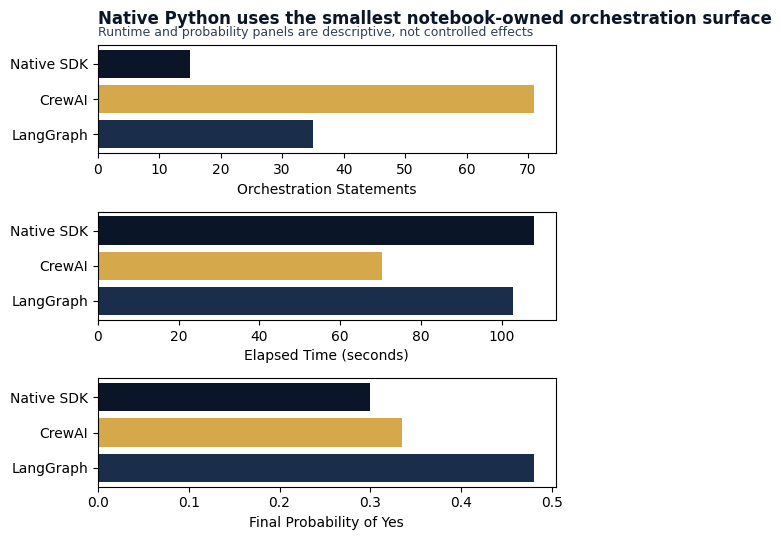

In [29]:
fig, axes = plt.subplots(3, 1, figsize=FIGSIZE["grid_3x2"])
panels = [
    ("statements", "Orchestration Statements"),
    ("elapsed_s", "Elapsed Time (seconds)"),
    ("final_p", "Final Probability of Yes"),
]
for ax, (column, label) in zip(axes, panels, strict=True):
    ax.barh(
        comparison_df["variant"],
        comparison_df[column],
        color=[COLORS["blue"], COLORS["amber"], COLORS["slate"]][: comparison_df.height],
    )
    ax.set_xlabel(label)
    ax.set_xlim(left=0)
    ax.invert_yaxis()
add_message_title(
    axes[0],
    "Native Python uses the smallest notebook-owned orchestration surface",
    subtitle="Runtime and probability panels are descriptive, not controlled effects",
)
fig.tight_layout()
fig.show()
plt.show()

The statement count covers the orchestration layer, not the agent classes.
CrewAI is the most verbose at the orchestration layer because each agent
carries a role / goal / backstory triple and each task carries a
description / expected_output / context list. LangGraph's overhead is
the typed state schema and four short node functions; once the schema is
defined, each node is a handful of statements. Native SDK is a single
function.

The `final_p` values are not expected to match. The CrewAI variant changes
prompts, agent classes, search access, and the client boundary. Native and
LangGraph are also separate stochastic model samples. Their gaps show why
orchestration comparisons need structural measures rather than forecast
agreement.

## Comparison matrix

| Dimension | Native SDK | CrewAI | LangGraph |
|---|---|---|---|
| **Orchestration shape** | function call stack | role-based agents in a `Crew` | `StateGraph` with typed nodes |
| **State location** | local variables | task outputs threaded by framework | explicit `TypedDict` |
| **Parallelism** | manual (threads / asyncio) | opt-in asynchronous tasks | conditional / parallel edges |
| **Checkpointing** | DIY, see NB03 | not first-class | first-class (`BaseCheckpointSaver` interface) |
| **LLM layer** | chapter `LLMClient` | LiteLLM (provider auto-detect) | passes through whatever the nodes use |
| **Debug entry point** | the line that raised | inside CrewAI's loop | `app.get_state(thread)` snapshot |
| **Full-trace capture** | one client wrapper | framework callbacks / verbose logs | one client wrapper |
| **Visual debugging** | print / pdb | verbose logs | graph rendering + state inspection |
| **Dep weight** | LLM SDK only | crewai + langchain transitives | langgraph + langchain transitives |
| **Learning curve** | low (Python only) | medium (roles / tasks / processes) | medium-high (graph + state) |

The differences that matter for a Chapter 24-shaped pipeline cluster in
two columns: LangGraph exposes an explicit checkpoint abstraction, while
native Python adds no orchestration dependency. Migration paths, observability stories, framework-momentum
trade-offs, and a longer discussion of when persistence /
parallelism / conditional-flow pressures justify a framework live in
§24.5 of the book rather than in the notebook.

## Key Takeaways

1. **Start native for this pipeline.** Plain Python has the smallest
   notebook-owned statement count and the most direct call stack in this
   implementation. That is local structural evidence, not a universal
   framework ranking.
2. **Reach for a framework only when a real pressure justifies it.**
   LangGraph exposes explicit checkpointing when crash recovery becomes a
   requirement. CrewAI's role / goal / backstory structure is most relevant
   when named personas are part of the design. Pin the selected versions.
3. **Variant B is not a controlled benchmark.** The CrewAI variant
   drives LiteLLM with role-prompted agents and does not share the
   chapter's specialist classes or search-tool surface, so any final-
   probability gap against Native or LangGraph is "different
   formulation," not "framework overhead."

**Next**: [`11_research_operator`](11_research_operator.ipynb) replays a
production-shaped operator loop against a real case-study registry.

**Book**: §24.5 covers migration paths, the persistence / parallelism /
conditional-flow pressure framing, and the ecosystem-version note in
the depth they deserve.